# ChemVL Upstream Inference Demo (CLI)

This notebook provides reproducible **upstream molecular descriptor inference** for **ChemVL**.

Given:
- a list of molecular descriptors (**MDs**) to predict, and
- a list of molecules as **SMILES** strings,

we call the Tier-1 CLI [`pretrain_inference.py`](../pretrain_inference.py) and read:
- `results.csv` (logits, ground truth, predictions per MD)
- optional rendered images under `images/`

## 1. Configure paths

Set `CHEMVL_DATA_ROOT` before running (see root README), or rely on auto-detection via `configure_chemvl_data_root()` (probes common data roots for the pretraining checkpoint). This notebook uses:
- the same OrdinalCLIP configs as the CLI
- checkpoint `{CHEMVL_DATA_ROOT}/checkpoints/pretraining/RN50px224.ckpt`
- output under `results/notebooks/a_md_inference/`

In [1]:
import sys
from pathlib import Path

NOTEBOOK_DIR = Path.cwd().resolve()
if NOTEBOOK_DIR.name == "notebooks":
    sys.path.insert(0, str(NOTEBOOK_DIR))
else:
    sys.path.insert(0, str(NOTEBOOK_DIR / "notebooks"))

from _notebook_utils import (
    repo_root,
    data_root,
    configure_chemvl_data_root,
    configure_quiet_demo_logging,
    ensure_repo_on_path,
    run_cmd,
    assert_paths_exist,
)

ROOT = ensure_repo_on_path()
configure_chemvl_data_root()
configure_quiet_demo_logging()
DATA = data_root()

CONFIGS = [
    str(ROOT / "ordinalclip/configs/default.yaml"),
    str(ROOT / "ordinalclip/configs/base_cfgs/data_cfg/datasets/mol-10M-106mds/local.yaml"),
]
CKPT = DATA / "checkpoints/pretraining/RN50px224.ckpt"
OUTPUT_DIR = ROOT / "results/notebooks/a_md_inference"
VALIDATION_CSV = DATA / "pretraining_datasets/10M-106mds/mds-validation.csv"

assert_paths_exist([CKPT], label="Pretrained checkpoint")

print("Repo root:", ROOT)
print("CHEMVL_DATA_ROOT:", DATA)
print("Checkpoint:", CKPT)
print("Output dir:", OUTPUT_DIR)

Repo root: /home/yhuang/projects/ChemVL-public-staging
CHEMVL_DATA_ROOT: /mnt/d/wsl-data/chemvl
Checkpoint: /mnt/d/wsl-data/chemvl/checkpoints/pretraining/RN50px224.ckpt
Output dir: /home/yhuang/projects/ChemVL-public-staging/results/notebooks/a_md_inference


## 2. Select MDs and molecules

- `mds`: descriptor tasks (subset of 106 supported tasks)
- `smiles`: molecules for inference

In [2]:
mds = [
    "fr_benzene",
    "fr_halogen",
    "NOCount",
    "NumHAcceptors",
    "NumRotatableBonds",
]

smiles = [
    "CCC(C)CCCCCCCCC(=O)OC[C@H](COP(=O)(O)OC[C@@H](COP(=O)(O)OC[C@@H](COC(=O)CCCCCCCCC(C)C)OC(=O)CCCCCCCCCCCCCCCCCC(C)C)O)OC(=O)CCCCCCCCCCCCCCCCCCC(C)C",
    "C1CN(CCN1C(=O)C(CC2=C(C=C(C=C2)Cl)Cl)N)C(=O)C3(C=CC=CC3C(F)(F)F)Cl",
    "C1=CC=C(C=C1)C2=CC=CC=C2NC3=C4C(=CC=C3)OC5=C4C=C(C=C5)C6=CC7=C(C=C6)OC8=C7C=C(C=C8)N9C1=CC=CC=C1N1C9=NC2=CC=CC=C21",
    "C1C(CN1C2=NC=C(C=N2)Cl)CN3C(=O)C=CC(=N3)C4=CN=CC=C4",
]

molecule_names = [f"Mol {i}" for i in range(len(smiles))]

print("MD tasks:", mds)
print("Num molecules:", len(smiles))

MD tasks: ['fr_benzene', 'fr_halogen', 'NOCount', 'NumHAcceptors', 'NumRotatableBonds']
Num molecules: 4


## 3. Run inference via CLI

Equivalent to:

```bash
python pretrain_inference.py -c ... --output_dir results/notebooks/a_md_inference \
  --mds ... --smiles ...
```

In [3]:
cmd = [sys.executable, str(ROOT / "pretrain_inference.py")]
for cfg in CONFIGS:
    cmd.extend(["-c", cfg])
cmd.extend(["--ckpt", str(CKPT)])
cmd.extend(["--output_dir", str(OUTPUT_DIR)])
for md_name in mds:
    cmd.extend(["--mds", md_name])
for smi in smiles:
    cmd.extend(["--smiles", smi])
for name in molecule_names:
    cmd.extend(["--names", name])

run_cmd(cmd, cwd=ROOT)
results_csv = OUTPUT_DIR / "results.csv"
assert results_csv.is_file(), f"Missing {results_csv}"
print("Results:", results_csv)

$ /home/yhuang/miniconda3/envs/chemvl/bin/python /home/yhuang/projects/ChemVL-public-staging/pretrain_inference.py -c /home/yhuang/projects/ChemVL-public-staging/ordinalclip/configs/default.yaml -c /home/yhuang/projects/ChemVL-public-staging/ordinalclip/configs/base_cfgs/data_cfg/datasets/mol-10M-106mds/local.yaml --ckpt /mnt/d/wsl-data/chemvl/checkpoints/pretraining/RN50px224.ckpt --output_dir /home/yhuang/projects/ChemVL-public-staging/results/notebooks/a_md_inference --mds fr_benzene --mds fr_halogen --mds NOCount --mds NumHAcceptors --mds NumRotatableBonds --smiles CCC(C)CCCCCCCCC(=O)OC[C@H](COP(=O)(O)OC[C@@H](COP(=O)(O)OC[C@@H](COC(=O)CCCCCCCCC(C)C)OC(=O)CCCCCCCCCCCCCCCCCC(C)C)O)OC(=O)CCCCCCCCCCCCCCCCCCC(C)C --smiles C1CN(CCN1C(=O)C(CC2=C(C=C(C=C2)Cl)Cl)N)C(=O)C3(C=CC=CC3C(F)(F)F)Cl --smiles C1=CC=C(C=C1)C2=CC=CC=C2NC3=C4C(=CC=C3)OC5=C4C=C(C=C5)C6=CC7=C(C=C6)OC8=C7C=C(C=C8)N9C1=CC=CC=C1N1C9=NC2=CC=CC=C21 --smiles C1C(CN1C2=NC=C(C=N2)Cl)CN3C(=O)C=CC(=N3)C4=CN=CC=C4 --names Mol 0 --

/home/yhuang/miniconda3/envs/chemvl/lib/python3.9/site-packages/pytorch_lightning/utilities/imports.py:22: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


Wrote /home/yhuang/projects/ChemVL-public-staging/results/notebooks/a_md_inference/results.csv


Results: /home/yhuang/projects/ChemVL-public-staging/results/notebooks/a_md_inference/results.csv


## 4. Visualize molecules and predictions

Read `results.csv` and show rendered structures (from sidecar `images/` when available).

,molecule_name,smiles,fr_benzene_logit,fr_benzene_gt_logit,fr_benzene_pred,fr_benzene_gt,fr_halogen_logit,fr_halogen_gt_logit,fr_halogen_pred,fr_halogen_gt,...,NOCount_pred,NOCount_gt,NumHAcceptors_logit,NumHAcceptors_gt_logit,NumHAcceptors_pred,NumHAcceptors_gt,NumRotatableBonds_logit,NumRotatableBonds_gt_logit,NumRotatableBonds_pred,NumRotatableBonds_gt
0,Mol 0,CCC(C)CCCCCCCCC(=O)OC[C@H](COP(=O)(O)OC[C@@H](...,0.962659,0.962659,0.0,0.0,0.953864,0.953864,0.0,0.0,...,17.0,17.0,0.888662,0.007970,17.0,15.0,0.276900,0.000226,72.0,74.0
1,Mol 1,C1CN(CCN1C(=O)C(CC2=C(C=C(C=C2)Cl)Cl)N)C(=O)C3...,0.996416,0.996416,1.0,1.0,0.560230,0.322679,5.0,6.0,...,5.0,5.0,0.554558,0.554558,3.0,3.0,0.623973,0.332109,3.0,4.0
2,Mol 2,C1=CC=C(C=C1)C2=CC=CC=C2NC3=C4C(=CC=C3)OC5=C4C...,0.502985,0.502985,8.0,8.0,0.972362,0.972362,0.0,0.0,...,6.0,6.0,0.644470,0.644470,6.0,6.0,0.459235,0.459235,5.0,5.0
3,Mol 3,C1C(CN1C2=NC=C(C=N2)Cl)CN3C(=O)C=CC(=N3)C4=CN=...,0.998257,0.998257,0.0,0.0,0.933863,0.933863,1.0,1.0,...,7.0,7.0,0.775246,0.775246,7.0,7.0,0.732269,0.732269,4.0,4.0


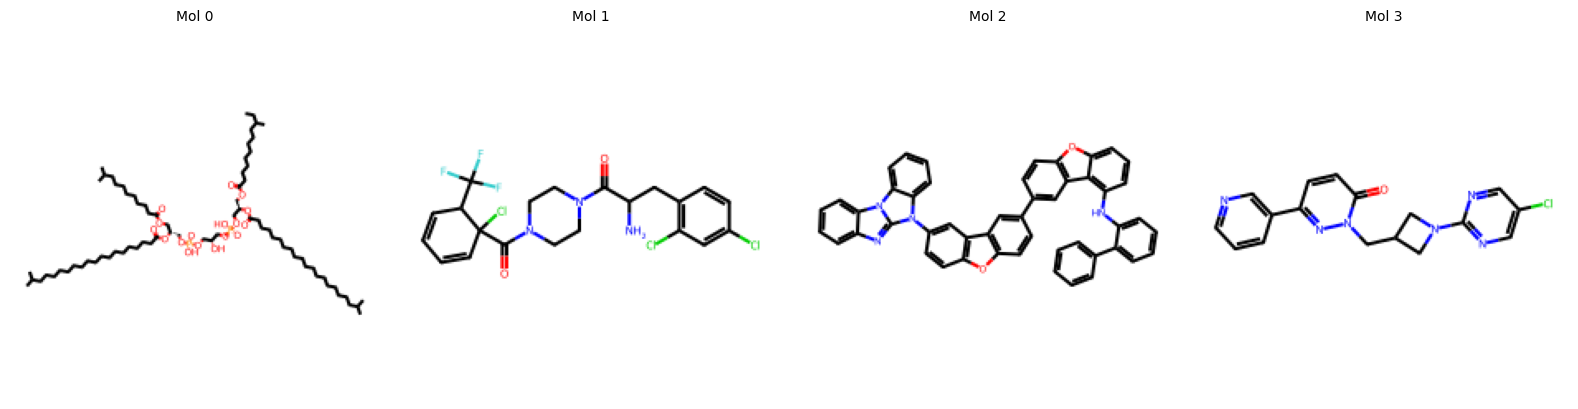

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

df = pd.read_csv(results_csv)
display(df)

img_dir = OUTPUT_DIR / "images"
num_mols = len(df)
fig, axes = plt.subplots(1, num_mols, figsize=(4 * num_mols, 4))
if num_mols == 1:
    axes = [axes]

for ax, (_, row) in zip(axes, df.iterrows()):
    idx = int(row.name) if hasattr(row, "name") else 0
    img_path = img_dir / f"{idx:03d}_{row['molecule_name']}.png"
    if not img_path.is_file():
        # fallback: any image with matching index prefix
        matches = sorted(img_dir.glob(f"{idx:03d}_*.png")) if img_dir.is_dir() else []
        img_path = matches[0] if matches else None
    if img_path and img_path.is_file():
        ax.imshow(Image.open(img_path))
    ax.axis("off")
    ax.set_title(str(row["molecule_name"]), fontsize=10)

plt.tight_layout()
plt.show()

## 5. Molecular descriptor inference on validation subset

Sample rows from the pre-training validation table via CLI (`--validation-csv`).

In [5]:
validation_out = ROOT / "results/notebooks/a_md_validation"
assert_paths_exist([VALIDATION_CSV], label="Validation CSV")

cmd = [sys.executable, str(ROOT / "pretrain_inference.py")]
for cfg in CONFIGS:
    cmd.extend(["-c", cfg])
cmd.extend([
    "--ckpt", str(CKPT),
    "--output_dir", str(validation_out),
    "--validation-csv", str(VALIDATION_CSV),
    "--num-samples", "10",
    "--seed", "0",
])
for md_name in mds:
    cmd.extend(["--mds", md_name])

run_cmd(cmd, cwd=ROOT)
val_df = pd.read_csv(validation_out / "results.csv")
val_df.head(10)

$ /home/yhuang/miniconda3/envs/chemvl/bin/python /home/yhuang/projects/ChemVL-public-staging/pretrain_inference.py -c /home/yhuang/projects/ChemVL-public-staging/ordinalclip/configs/default.yaml -c /home/yhuang/projects/ChemVL-public-staging/ordinalclip/configs/base_cfgs/data_cfg/datasets/mol-10M-106mds/local.yaml --ckpt /mnt/d/wsl-data/chemvl/checkpoints/pretraining/RN50px224.ckpt --output_dir /home/yhuang/projects/ChemVL-public-staging/results/notebooks/a_md_validation --validation-csv /mnt/d/wsl-data/chemvl/pretraining_datasets/10M-106mds/mds-validation.csv --num-samples 10 --seed 0 --mds fr_benzene --mds fr_halogen --mds NOCount --mds NumHAcceptors --mds NumRotatableBonds


/home/yhuang/miniconda3/envs/chemvl/lib/python3.9/site-packages/pytorch_lightning/utilities/imports.py:22: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


Wrote /home/yhuang/projects/ChemVL-public-staging/results/notebooks/a_md_validation/results.csv


,molecule_name,smiles,fr_benzene_logit,fr_benzene_gt_logit,fr_benzene_pred,fr_benzene_gt,fr_halogen_logit,fr_halogen_gt_logit,fr_halogen_pred,fr_halogen_gt,...,NOCount_pred,NOCount_gt,NumHAcceptors_logit,NumHAcceptors_gt_logit,NumHAcceptors_pred,NumHAcceptors_gt,NumRotatableBonds_logit,NumRotatableBonds_gt_logit,NumRotatableBonds_pred,NumRotatableBonds_gt
0,9534207,O=[N+]([O-])C1CC[NH+](Cc2ccccc2)CC1,0.997879,0.997879,1.0,1.0,0.996720,0.996720,0.0,0.0,...,4.0,4.0,0.760355,0.760355,2.0,2.0,0.882978,0.882978,3.0,3.0
1,9570541,CC[NH2+]C(C)CNC(=O)c1cnn(c2ccc(C(F)(F)F)cn2)c1...,0.998578,0.998578,0.0,0.0,0.983451,0.983451,3.0,3.0,...,6.0,6.0,0.909208,0.909208,4.0,4.0,0.714454,0.714454,7.0,7.0
2,9713126,COc1cc(COO)cc(COO)c1,0.996016,0.996016,1.0,1.0,0.991054,0.991054,0.0,0.0,...,4.0,5.0,0.776453,0.214504,4.0,5.0,0.708392,0.708392,5.0,5.0
3,9817624,O=C([O-])CCC(=O)N(C1CC1)C1CCSC1,0.998660,0.998660,0.0,0.0,0.998512,0.998512,0.0,0.0,...,4.0,4.0,0.972484,0.972484,4.0,4.0,0.732986,0.732986,5.0,5.0
4,9774085,O=[N+]([O-])c1cccc(F)c1Oc1cccc(Br)n1,0.992433,0.992433,1.0,1.0,0.967467,0.967467,2.0,2.0,...,5.0,5.0,0.953766,0.953766,4.0,4.0,0.918247,0.918247,3.0,3.0
5,9851507,CC1CCC(=[NH+]C(=[NH+]c2ccccc2)N2CCCC2)N1C,0.991222,0.991222,1.0,1.0,0.988216,0.988216,0.0,0.0,...,4.0,4.0,0.531568,0.456946,1.0,0.0,0.539467,0.539467,1.0,1.0
6,9784755,O=C(c1ccco1)N1CCN(c2nnc(Cc3ccncc3)c3ccccc23)CC1,0.986622,0.986622,1.0,1.0,0.984246,0.984246,0.0,0.0,...,7.0,7.0,0.902635,0.902635,6.0,6.0,0.753773,0.753773,4.0,4.0
7,9656684,O=C(NCc1ccccn1)C(C1CCCC1)[NH+]1CCN(C(=O)c2ccc(...,0.996245,0.996245,1.0,1.0,0.986040,0.986040,0.0,0.0,...,9.0,9.0,0.553920,0.553920,5.0,5.0,0.636685,0.636685,7.0,7.0
8,9691550,Cc1c([N+](=O)[O-])cccc1S(=O)(=O)N1CCc2ccc(F)cc...,0.997400,0.997400,2.0,2.0,0.968267,0.968267,1.0,1.0,...,6.0,6.0,0.753176,0.753176,4.0,4.0,0.826661,0.826661,3.0,3.0
9,9918235,CCNC(=NCC1CCCC[NH+]1CC)NC1CCCn2nc(C)nc21,0.998323,0.998323,0.0,0.0,0.991590,0.991590,0.0,0.0,...,7.0,7.0,0.806299,0.806299,4.0,4.0,0.604160,0.604160,5.0,5.0


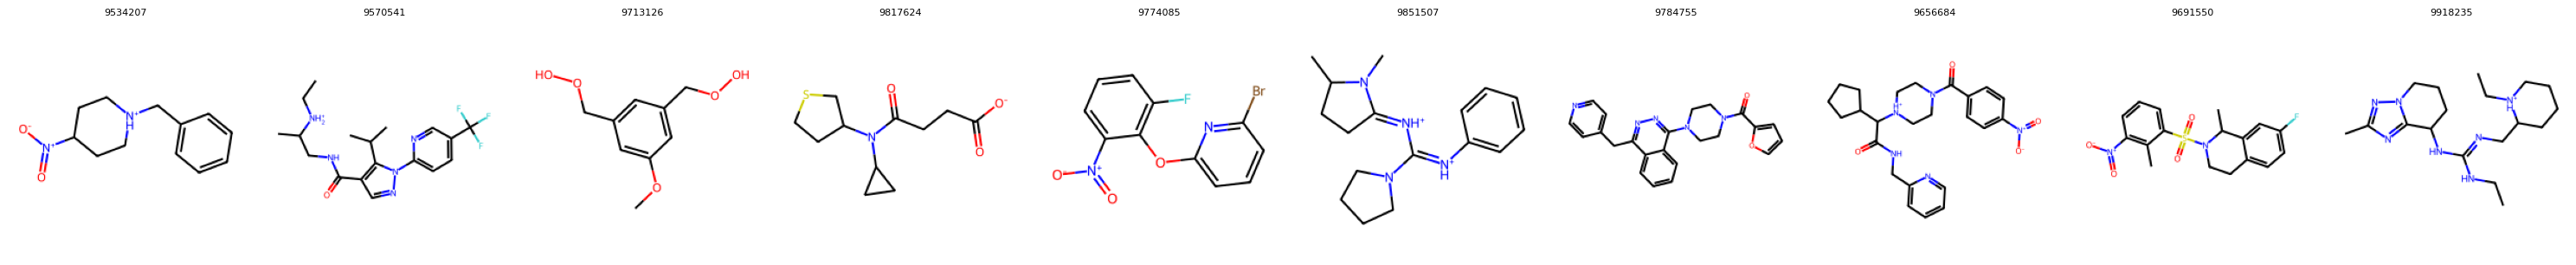

,molecule_name,smiles,fr_benzene_logit,fr_benzene_gt_logit,fr_benzene_pred,fr_benzene_gt,fr_halogen_logit,fr_halogen_gt_logit,fr_halogen_pred,fr_halogen_gt,...,NOCount_pred,NOCount_gt,NumHAcceptors_logit,NumHAcceptors_gt_logit,NumHAcceptors_pred,NumHAcceptors_gt,NumRotatableBonds_logit,NumRotatableBonds_gt_logit,NumRotatableBonds_pred,NumRotatableBonds_gt
0,9534207,O=[N+]([O-])C1CC[NH+](Cc2ccccc2)CC1,0.997879,0.997879,1.0,1.0,0.996720,0.996720,0.0,0.0,...,4.0,4.0,0.760355,0.760355,2.0,2.0,0.882978,0.882978,3.0,3.0
1,9570541,CC[NH2+]C(C)CNC(=O)c1cnn(c2ccc(C(F)(F)F)cn2)c1...,0.998578,0.998578,0.0,0.0,0.983451,0.983451,3.0,3.0,...,6.0,6.0,0.909208,0.909208,4.0,4.0,0.714454,0.714454,7.0,7.0
2,9713126,COc1cc(COO)cc(COO)c1,0.996016,0.996016,1.0,1.0,0.991054,0.991054,0.0,0.0,...,4.0,5.0,0.776453,0.214504,4.0,5.0,0.708392,0.708392,5.0,5.0
3,9817624,O=C([O-])CCC(=O)N(C1CC1)C1CCSC1,0.998660,0.998660,0.0,0.0,0.998512,0.998512,0.0,0.0,...,4.0,4.0,0.972484,0.972484,4.0,4.0,0.732986,0.732986,5.0,5.0
4,9774085,O=[N+]([O-])c1cccc(F)c1Oc1cccc(Br)n1,0.992433,0.992433,1.0,1.0,0.967467,0.967467,2.0,2.0,...,5.0,5.0,0.953766,0.953766,4.0,4.0,0.918247,0.918247,3.0,3.0
5,9851507,CC1CCC(=[NH+]C(=[NH+]c2ccccc2)N2CCCC2)N1C,0.991222,0.991222,1.0,1.0,0.988216,0.988216,0.0,0.0,...,4.0,4.0,0.531568,0.456946,1.0,0.0,0.539467,0.539467,1.0,1.0
6,9784755,O=C(c1ccco1)N1CCN(c2nnc(Cc3ccncc3)c3ccccc23)CC1,0.986622,0.986622,1.0,1.0,0.984246,0.984246,0.0,0.0,...,7.0,7.0,0.902635,0.902635,6.0,6.0,0.753773,0.753773,4.0,4.0
7,9656684,O=C(NCc1ccccn1)C(C1CCCC1)[NH+]1CCN(C(=O)c2ccc(...,0.996245,0.996245,1.0,1.0,0.986040,0.986040,0.0,0.0,...,9.0,9.0,0.553920,0.553920,5.0,5.0,0.636685,0.636685,7.0,7.0
8,9691550,Cc1c([N+](=O)[O-])cccc1S(=O)(=O)N1CCc2ccc(F)cc...,0.997400,0.997400,2.0,2.0,0.968267,0.968267,1.0,1.0,...,6.0,6.0,0.753176,0.753176,4.0,4.0,0.826661,0.826661,3.0,3.0
9,9918235,CCNC(=NCC1CCCC[NH+]1CC)NC1CCCn2nc(C)nc21,0.998323,0.998323,0.0,0.0,0.991590,0.991590,0.0,0.0,...,7.0,7.0,0.806299,0.806299,4.0,4.0,0.604160,0.604160,5.0,5.0


In [6]:
img_dir = validation_out / "images"
num_mols = min(10, len(val_df))
fig, axes = plt.subplots(1, num_mols, figsize=(3 * num_mols, 3))
if num_mols == 1:
    axes = [axes]

for ax, (i, (_, row)) in zip(axes, enumerate(val_df.head(num_mols).iterrows())):
    matches = sorted(img_dir.glob(f"{i:03d}_*.png")) if img_dir.is_dir() else []
    if matches:
        ax.imshow(Image.open(matches[0]))
    ax.axis("off")
    ax.set_title(str(row["molecule_name"]), fontsize=8)

plt.tight_layout()
plt.show()
val_df.head(10)